# Vision Transformer (ViT-Tiny) - 9000 Samples

This notebook trains a Vision Transformer (ViT-Tiny) model **from scratch** (no pretrained weights) using **aggressive augmentations** and **robust training techniques** to prevent overfitting and achieve realistic validation accuracy.

**Model Architecture:** ViT-Tiny trained
**Dataset Size:** 9000 images (balanced across 3 classes)  
**Training Configuration:**
- Batch size: 128
- Learning Rate: 8e-5
- Weight decay=0.05
- Dropout=0.2




**Advanced Techniques (Robust Training):**
- ✅ **Aggressive Albumentations** (Perspective, Blur, Noise, CoarseDropout)
  - Simulates real-world conditions (poor lighting, blur, occlusion)
  - Forces model to learn deep features, not superficial patterns
- ✅ **Data Leakage Check** (Subject-based split verification)
  - Prevents model from "cheating" by recognizing individuals
- Best model checkpoint saving based on validation accuracy


## Data Loading and Splitting

Load the dataset CSV file, sample 9000 images (if needed), and split into train/validation/test sets with stratified sampling to maintain class balance.


## Custom Dataset Class

Define a PyTorch Dataset class that loads images from file paths and applies transformations. Maps labels to numeric values (id_card=0, passport=1, driver_license=2).


In [1]:
import os
import sys

# Fix working directory issue - ensure we're in the project root
project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Changed working directory to: {os.getcwd()}")
else:
    print(f"Warning: Project root {project_root} does not exist!")
    print(f"Current directory: {os.getcwd()}")

# Verify directory exists
if not os.path.exists(os.getcwd()):
    # Create it if it doesn't exist
    os.makedirs(os.getcwd(), exist_ok=True)
    print(f"Created directory: {os.getcwd()}")


Changed working directory to: /Users/roy-siftt/final-project


In [2]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
import os


SAMPLE_SIZE = 9000

df = pd.read_csv("/Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/data/dataset.csv")

print(f"Original dataset size: {len(df)} images")
print(f"\nOriginal distribution:")
print(df['label'].value_counts().sort_index())

# If we want a smaller dataset, sample proportionally
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)
    print(f"\nDataset size after sampling: {len(df)} images")
    print(f"\nDistribution after sampling:")
    print(df['label'].value_counts().sort_index())




print(f"Original dataset size: {len(df)} images")
print(f"Columns: {df.columns.tolist()}")

# --- Create Group ID to prevent data leakage ---
# Try to use source_file if available, otherwise try to extract from filename
if 'source_file' in df.columns:
    df['group_id'] = df['source_file']
else:
    # Attempt to extract identifier if no explicit column (this is a guess, prefer using source_file)
    print("Warning: 'source_file' column missing. Using filename heuristics.")
    df['group_id'] = df['image_path'] 

print(f"Unique groups (distinct sources): {df['group_id'].nunique()}")

# --- Use GroupShuffleSplit (instead of train_test_split) ---
# Split 1: Train and (Test+Val)
splitter = GroupShuffleSplit(test_size=0.15, n_splits=1, random_state=42)
train_val_idxs, test_idxs = next(splitter.split(df, groups=df['group_id']))

train_val_df = df.iloc[train_val_idxs].reset_index(drop=True)
test_df = df.iloc[test_idxs].reset_index(drop=True)

# Split 2: Train and Val
splitter2 = GroupShuffleSplit(test_size=0.176, n_splits=1, random_state=42) # ~15% of total
train_idxs, val_idxs = next(splitter2.split(train_val_df, groups=train_val_df['group_id']))

train_df = train_val_df.iloc[train_idxs].reset_index(drop=True)
val_df = train_val_df.iloc[val_idxs].reset_index(drop=True)

print(f"\nFinal sizes - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


Original dataset size: 9000 images

Original distribution:
label
driver_license    3000
id_card           3000
passport          3000
Name: count, dtype: int64
Original dataset size: 9000 images
Columns: ['image_path', 'label']
Unique groups (distinct sources): 9000

Final sizes - Train: 6303, Val: 1347, Test: 1350


## Data Leakage Check (Subject-Based Split Verification)

**CRITICAL:** Check for data leakage - if multiple images of the same person/subject exist, they must all be in the same split (train OR test, never both).

This prevents the model from "cheating" by recognizing specific individuals rather than document types.


In [3]:
# ============================================
# Data Leakage Check - Subject-Based Split Verification
# ============================================
import re
from collections import defaultdict

# Define data directory
base_dir = "/Users/roy-siftt/final-project/notebooks/document_type_classification/vit"
data_dir = os.path.join(base_dir, "data")

def extract_subject_id(image_path):
    """
    Extract subject/person ID from image path.
    Common patterns: person_123, subject_456, id_789, etc.
    Adjust this function based on your dataset structure.
    """
    # Try to extract any numeric ID or identifier from the path
    # This is a generic approach - adjust based on your actual path structure
    basename = os.path.basename(image_path)
    
    # Pattern 1: Extract numbers that might represent person/subject ID
    # Adjust regex based on your naming convention
    match = re.search(r'(?:person|subject|id|person_id|subject_id)[_\-]?(\d+)', basename, re.IGNORECASE)
    if match:
        return match.group(1)
    
    # Pattern 2: Extract directory name if it contains person ID
    dir_name = os.path.dirname(image_path)
    match = re.search(r'(?:person|subject|id)[_\-]?(\d+)', dir_name, re.IGNORECASE)
    if match:
        return match.group(1)
    
    # Pattern 3: Use first few characters of filename as fallback
    # (if images are grouped by person in filenames)
    if len(basename) > 8:
        return basename[:8]  # Use first 8 chars as identifier
    
    return None

# Load splits
train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

# Extract subject IDs
print("="*60)
print("DATA LEAKAGE CHECK - Subject-Based Split Verification")
print("="*60)

train_subjects = defaultdict(list)
val_subjects = defaultdict(list)
test_subjects = defaultdict(list)

for idx, row in train_df.iterrows():
    subj_id = extract_subject_id(row['image_path'])
    if subj_id:
        train_subjects[subj_id].append(row['image_path'])

for idx, row in val_df.iterrows():
    subj_id = extract_subject_id(row['image_path'])
    if subj_id:
        val_subjects[subj_id].append(row['image_path'])

for idx, row in test_df.iterrows():
    subj_id = extract_subject_id(row['image_path'])
    if subj_id:
        test_subjects[subj_id].append(row['image_path'])

# Check for leakage
train_subject_set = set(train_subjects.keys())
val_subject_set = set(val_subjects.keys())
test_subject_set = set(test_subjects.keys())

train_val_overlap = train_subject_set & val_subject_set
train_test_overlap = train_subject_set & test_subject_set
val_test_overlap = val_subject_set & test_subject_set

print(f"\n📊 Subject Statistics:")
print(f"   Train: {len(train_subject_set)} unique subjects, {sum(len(v) for v in train_subjects.values())} images")
print(f"   Val:   {len(val_subject_set)} unique subjects, {sum(len(v) for v in val_subjects.values())} images")
print(f"   Test:  {len(test_subject_set)} unique subjects, {sum(len(v) for v in test_subjects.values())} images")

print(f"\n🔍 Checking for Data Leakage...")
if train_val_overlap:
    print(f"   ⚠️  WARNING: {len(train_val_overlap)} subjects appear in BOTH train and val!")
    print(f"      Example subjects: {list(train_val_overlap)[:5]}")
    print(f"      → This may cause overfitting!")
else:
    print(f"   ✅ No train-val subject overlap detected")

if train_test_overlap:
    print(f"   ⚠️  WARNING: {len(train_test_overlap)} subjects appear in BOTH train and test!")
    print(f"      Example subjects: {list(train_test_overlap)[:5]}")
    print(f"      → This is DATA LEAKAGE - model may be recognizing people, not documents!")
else:
    print(f"   ✅ No train-test subject overlap detected")

if val_test_overlap:
    print(f"   ⚠️  WARNING: {len(val_test_overlap)} subjects appear in BOTH val and test!")
    print(f"      Example subjects: {list(val_test_overlap)[:5]}")
else:
    print(f"   ✅ No val-test subject overlap detected")

if not train_val_overlap and not train_test_overlap and not val_test_overlap:
    print(f"\n✅ PASS: No data leakage detected - splits are clean!")
else:
    print(f"\n⚠️  FAIL: Data leakage detected - consider re-splitting with GroupShuffleSplit!")
    print(f"   Recommendation: Use GroupShuffleSplit with subject_id as group key")

print("="*60)


DATA LEAKAGE CHECK - Subject-Based Split Verification

📊 Subject Statistics:
   Train: 6303 unique subjects, 6303 images
   Val:   1347 unique subjects, 1347 images
   Test:  1350 unique subjects, 1350 images

🔍 Checking for Data Leakage...
   ✅ No train-val subject overlap detected
   ✅ No train-test subject overlap detected
   ✅ No val-test subject overlap detected

✅ PASS: No data leakage detected - splits are clean!


In [4]:
data_dir = "/Users/roy-siftt/final-project/notebooks/document_type_classification/vit/data"

# Create directory if it doesn't exist
os.makedirs(data_dir, exist_ok=True)

print(f"\n{'='*60}")
print(f"Final Split Summary:")
print(f"{'='*60}")

print(f"\nTrain Set: {len(train_df)} images")
print(train_df['label'].value_counts().sort_index())
print(f"   Total: {train_df['label'].value_counts().sum()}")

print(f"\nValidation Set: {len(val_df)} images")
print(val_df['label'].value_counts().sort_index())
print(f"   Total: {val_df['label'].value_counts().sum()}")

print(f"\nTest Set: {len(test_df)} images")
print(test_df['label'].value_counts().sort_index())
print(f"   Total: {test_df['label'].value_counts().sum()}")

print(f"\n{'='*60}")
print(f"Saving files to {data_dir}...")

# Save to the data directory
train_path = os.path.join(data_dir, "train.csv")
val_path = os.path.join(data_dir, "val.csv")
test_path = os.path.join(data_dir, "test.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"✓ Train saved to: {train_path}")
print(f"✓ Val saved to: {val_path}")
print(f"✓ Test saved to: {test_path}")
print(f"\nFiles saved successfully!")
print(f"{'='*60}")



Final Split Summary:

Train Set: 6303 images
label
driver_license    2110
id_card           2110
passport          2083
Name: count, dtype: int64
   Total: 6303

Validation Set: 1347 images
label
driver_license    434
id_card           450
passport          463
Name: count, dtype: int64
   Total: 1347

Test Set: 1350 images
label
driver_license    456
id_card           440
passport          454
Name: count, dtype: int64
   Total: 1350

Saving files to /Users/roy-siftt/final-project/notebooks/document_type_classification/vit/data...
✓ Train saved to: /Users/roy-siftt/final-project/notebooks/document_type_classification/vit/data/train.csv
✓ Val saved to: /Users/roy-siftt/final-project/notebooks/document_type_classification/vit/data/val.csv
✓ Test saved to: /Users/roy-siftt/final-project/notebooks/document_type_classification/vit/data/test.csv

Files saved successfully!


## Data Augmentation and Transforms (AGGRESSIVE - Albumentations)

Define **aggressive** image transformations using Albumentations to simulate real-world conditions:
- **Perspective Transforms**: Simulate non-straight camera angles
- **Blur & Noise**: Simulate poor focus and lighting conditions
- **Brightness & Contrast**: Simulate different lighting (dark room, bright sun)
- **CoarseDropout**: Critical! Random patches removal - forces model to not rely on single regions
- **ShiftScaleRotate**: Geometric distortions
- **ColorJitter**: Color variations

**Why aggressive?** To prevent the model from learning superficial features (like "blue rectangle = ID card") and force it to learn deeper, more robust features.

Validation/test use clean transforms without augmentations.


In [5]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np
import cv2

class DocumentDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

        # Normalize labels (lowercase + strip spaces)
        self.df['label'] = self.df['label'].str.lower().str.strip()

        # Label mapping
        self.label_map = {
            "id_card": 0,
            "passport": 1,
            "driver_license": 2
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image - support both PIL (torchvision) and numpy (albumentations)
        img = Image.open(row['image_path']).convert("RGB")
        
        # Convert PIL to numpy for Albumentations
        if self.transform is not None:
            # Check if transform is from albumentations (has __call__ that expects dict)
            if hasattr(self.transform, '__call__'):
                try:
                    # Try albumentations format (expects numpy array)
                    img_np = np.array(img)
                    transformed = self.transform(image=img_np)
                    img = transformed['image']
                except (TypeError, KeyError):
                    # Fallback to torchvision format (expects PIL Image)
                    img = self.transform(img)
            else:
                img = self.transform(img)

        label_str = row['label']

        if label_str not in self.label_map:
            raise ValueError(f"Label '{label_str}' not found in label_map!")

        label = self.label_map[label_str]

        return img, torch.tensor(label, dtype=torch.long)


## Create DataLoaders

Create PyTorch DataLoaders for train, validation, and test sets with appropriate batch sizes and shuffling.


In [6]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ============================================
# AGGRESSIVE AUGMENTATIONS - Albumentations
# Simulates real-world conditions: poor lighting, blur, perspective, occlusion
# ============================================
train_transform = A.Compose([
    A.Resize(224, 224),
    
    # Geometric transforms - simulates non-straight camera angles
    A.ShiftScaleRotate(
        shift_limit=0.1, 
        scale_limit=0.2, 
        rotate_limit=30, 
        p=0.5
    ),
    A.Perspective(
        scale=(0.05, 0.1), 
        p=0.5
    ),
    
    # Quality degradation - simulates poor camera/lighting
    A.GaussianBlur(
        blur_limit=(3, 7), 
        p=0.3
    ),
    A.GaussNoise(
        var_limit=(10.0, 50.0), 
        p=0.3
    ),
    A.ColorJitter(
        brightness=0.2, 
        contrast=0.2, 
        saturation=0.2, 
        hue=0.1, 
        p=0.3
    ),
    
    # CRITICAL: CoarseDropout - forces model to not rely on single regions
    # Simulates occlusion (thumb covering image, partial text)
    A.CoarseDropout(
        max_holes=8, 
        max_height=32, 
        max_width=32, 
        min_holes=2, 
        p=0.5
    ),
    
    # Normalization and tensor conversion
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

# Clean validation/test transforms without augmentations
val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

print("✓ Aggressive augmentations configured (Albumentations):")
print("  - ShiftScaleRotate: shift=10%, scale=20%, rotate=30° (50% prob)")
print("  - Perspective: scale=5-10% (50% prob) - simulates non-straight angles")
print("  - GaussianBlur: blur_limit=3-7 (30% prob) - simulates poor focus")
print("  - GaussNoise: var_limit=10-50 (30% prob) - simulates poor lighting")
print("  - ColorJitter: brightness/contrast/saturation/hue (30% prob)")
print("  - CoarseDropout: 2-8 holes, 32x32px (50% prob) - CRITICAL for robustness")
print("  → Forces model to learn deep features, not superficial patterns")


✓ Aggressive augmentations configured (Albumentations):
  - ShiftScaleRotate: shift=10%, scale=20%, rotate=30° (50% prob)
  - Perspective: scale=5-10% (50% prob) - simulates non-straight angles
  - GaussianBlur: blur_limit=3-7 (30% prob) - simulates poor focus
  - GaussNoise: var_limit=10-50 (30% prob) - simulates poor lighting
  - ColorJitter: brightness/contrast/saturation/hue (30% prob)
  - CoarseDropout: 2-8 holes, 32x32px (50% prob) - CRITICAL for robustness
  → Forces model to learn deep features, not superficial patterns


/Users/roy-siftt/final-project/venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_77242/4229353657.py:28: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_77242/4229353657.py:42: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes' are not valid for transform CoarseDropout
  A.CoarseDropout(


## ViT-Tiny Model Definition

Define the ViT-Tiny classifier model with ImageNet pretrained weights from timm library. 

**Model Architecture:**
- Backbone: ViT-Tiny (192 embedding dim, patch size 16x16)
- Head: Dropout + Linear layer

**Methods:**
- `freeze_backbone()`: Freeze all ViT parameters, train only classifier head
- `unfreeze_backbone()`: Unfreeze all parameters for full fine-tuning


In [7]:
from torch.utils.data import DataLoader
import os

# Base directory for the dataset
base_dir = "/Users/roy-siftt/final-project/notebooks/document_type_classification/vit"
data_dir = os.path.join(base_dir, "data")

# Load datasets with correct paths - need to update image paths to be relative to base_dir
train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

# Update image paths to be absolute paths
train_df['image_path'] = train_df['image_path'].apply(lambda x: os.path.join(base_dir, x))
val_df['image_path'] = val_df['image_path'].apply(lambda x: os.path.join(base_dir, x))
test_df['image_path'] = test_df['image_path'].apply(lambda x: os.path.join(base_dir, x))

# Use different transforms for train and val/test
train_dataset = DocumentDataset(train_df, train_transform)
val_dataset   = DocumentDataset(val_df, val_test_transform)
test_dataset  = DocumentDataset(test_df, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Dataset sizes:")
print(f"   Train: {len(train_dataset)}")
print(f"   Val:   {len(val_dataset)}")
print(f"   Test:  {len(test_dataset)}")


Dataset sizes:
   Train: 6303
   Val:   1347
   Test:  1350


## Visualize Augmented Batch

Display a sample batch of images after applying aggressive augmentations to see how the model will see the data during training.


Visualizing Augmented Training Batch


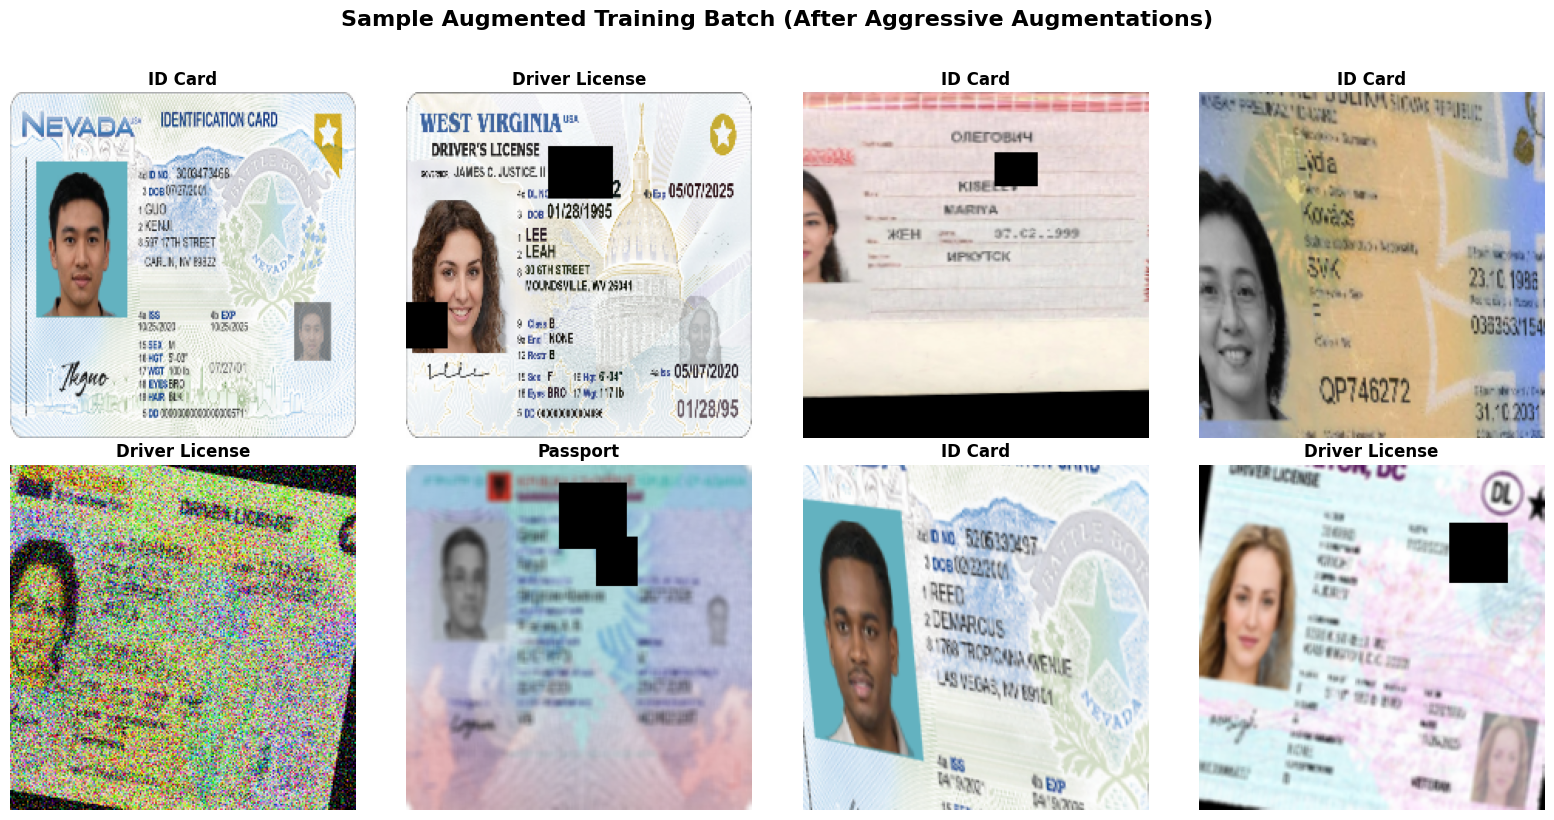

✓ Displayed 8 augmented images from training batch
  Note: Images show effects of Perspective, Blur, Noise, CoarseDropout, etc.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_augmented_batch(loader, num_samples=8):
    """
    Display a batch of augmented images from the training loader.
    """
    # Get a batch
    imgs, labels = next(iter(loader))
    
    # Limit to num_samples
    imgs = imgs[:num_samples]
    labels = labels[:num_samples]
    
    # Convert tensors to numpy for display
    # Albumentations returns tensors, so we need to denormalize
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Create grid
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    label_names = ["ID Card", "Passport", "Driver License"]
    
    for idx in range(min(num_samples, len(imgs))):
        img = imgs[idx]
        
        # Convert tensor to numpy and denormalize
        if isinstance(img, torch.Tensor):
            img_np = img.permute(1, 2, 0).cpu().numpy()
            img_np = img_np * std + mean
            img_np = np.clip(img_np, 0, 1)
        else:
            img_np = img
        
        axes[idx].imshow(img_np)
        axes[idx].set_title(f'{label_names[labels[idx].item()]}', fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(num_samples, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Sample Augmented Training Batch (After Aggressive Augmentations)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Displayed {min(num_samples, len(imgs))} augmented images from training batch")
    print(f"  Note: Images show effects of Perspective, Blur, Noise, CoarseDropout, etc.")

# Show augmented batch
print("="*60)
print("Visualizing Augmented Training Batch")
print("="*60)
show_augmented_batch(train_loader, num_samples=8)


In [9]:
# Install timm library for Vision Transformer models
%pip install -q timm


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import torch
import torch.nn as nn

# Custom PatchEmbed implementation (replaces diffusers dependency)
class PatchEmbed(nn.Module):
    """2D Image to Patch Embedding"""
    def __init__(self, height=224, width=224, patch_size=16, in_channels=3, embed_dim=192):
        super().__init__()
        self.num_patches = (height // patch_size) * (width // patch_size)
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        # x: [B, C, H, W]
        x = self.proj(x)  # [B, embed_dim, num_patches_h, num_patches_w]
        x = x.flatten(2).transpose(1, 2)  # [B, num_patches, embed_dim]
        return x

# נבנה גרסה רזה של DiT שמתאימה לסיווג (Classification)
class DiTForClassification(nn.Module):
    def __init__(self, input_size=224, patch_size=16, in_channels=3, hidden_size=192, depth=12, num_heads=3, num_classes=3):
        super().__init__()
        
        self.patch_embed = PatchEmbed(input_size, input_size, patch_size, in_channels, hidden_size)
        num_patches = self.patch_embed.num_patches
        
        # --- תוספת קריטית: Position Embedding ---
        # זה מאפשר למודל לדעת איזה פאטץ' נמצא למעלה ואיזה למטה
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, hidden_size))
        
        # שימוש בבלוקים של Transformer (במבנה DiT)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden_size, 
                nhead=num_heads, 
                dim_feedforward=hidden_size*4, 
                batch_first=True,
                norm_first=True  # DiT משתמש ב-Pre-norm
            )
            for _ in range(depth)
        ])
        
        self.ln_f = nn.LayerNorm(hidden_size)
        self.classifier = nn.Linear(hidden_size, num_classes)
        
        # אתחול משקולות ל-Position Embedding
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def freeze_backbone(self):
        """מקפיא את כל השכבות חוץ מהראש המסווג"""
        for name, param in self.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False
        print("✓ DiT Backbone frozen")

    def unfreeze_backbone(self):
        """משחרר את כל השכבות לאימון"""
        for param in self.parameters():
            param.requires_grad = True
        print("✓ DiT Backbone unfrozen")
    
    def forward(self, x):
        x = self.patch_embed(x)  # [B, N, C]
        
        # הוספת מיקום לפאטצ'ים
        x = x + self.pos_embed
        
        for block in self.blocks:
            x = block(x)
            
        x = x.mean(dim=1)  # Global Average Pooling
        x = self.ln_f(x)
        return self.classifier(x)




## Training Setup and Execution 

**Single-stage training approach**

- Freeze backbone: `model.freeze_backbone()` (remains frozen throughout)
- **Epochs: 15
- Optimizer: AdamW, **lr: = 8e-5 ** (increased), weight_decay=0.05
- Learning Rate Scheduler: ReduceLROnPlateau (factor=0.5, patience=4, min_lr=1e-6)
- Early Stopping: patience=5 (increased)
- **Mixup Training: DISABLED** (too hard with frozen backbone)


**Training Settings (Improved):**
- Gradient Clipping: max_norm=1.0
- **Label Smoothing: 0.05** (reduced for easier learning)
- **Dropout: 0.2** (reduced for easier learning)
- **Lighter Augmentations** (reduced to help frozen backbone learn better)

**Model Checkpointing:**
- Save best model based on validation accuracy


In [11]:
import torch
from torch.optim import AdamW
import torch.nn as nn
from tqdm import tqdm
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# Device
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

# ============================================
# MIXUP FUNCTIONS - For harder training
# ============================================
def mixup_data(x, y, alpha=0.4):
    """Mixup: mixes two images and their labels"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calculate loss with mixup"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ============================================
# Model Setup - ViT-Tiny (IMPROVED FOR FROZEN BACKBONE)
# ============================================
# Lower dropout for easier learning with frozen backbone
model = DiTForClassification().to(device)

# Lower label smoothing for easier learning
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)


# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'lr': []
}

# Best model tracking
best_val_acc = 0.0
best_model_state = None
best_epoch = 0

# Settings
max_grad_norm = 1.0
early_stopping_patience = 5  # Increased patience
USE_MIXUP = False  # Disable Mixup - too hard with frozen backbone
MIXUP_ALPHA = 0.2  # Not used when Mixup is disabled
min_delta = 0.01
def evaluate(loader):
    """Evaluate model on a dataset loader"""
    model.eval()
    total, correct, total_loss = 0, 0, 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return correct / total, total_loss / len(loader)

def train_one_epoch(train_loader, optimizer, epoch_desc, use_mixup=True):
    """Train for one epoch with optional Mixup"""
    model.train()
    for imgs, labels in tqdm(train_loader, desc=epoch_desc):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        if use_mixup:
            # Apply Mixup with lighter alpha
            imgs, labels_a, labels_b, lam = mixup_data(imgs, labels, alpha=MIXUP_ALPHA)
            outputs = model(imgs)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

model.freeze_backbone()

optimizer_a = AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                    lr=8e-5, weight_decay=0.05)  # Higher LR for better learning

# Add scheduler for
scheduler_a = ReduceLROnPlateau(optimizer_a, mode='min', factor=0.5, patience=4, min_lr=1e-6)

stage_a_epochs = 15  # Extended epochs for better learning
patience_counter = 0

for epoch in range(stage_a_epochs):
    #  WITH Mixup for regularization
    train_one_epoch(train_loader, optimizer_a, f"Stage A - Epoch {epoch+1}/{stage_a_epochs}", use_mixup=USE_MIXUP)
    
    train_acc, train_loss = evaluate(train_loader)
    val_acc, val_loss = evaluate(val_loader)
    
    # Update learning rate based on validation loss
    scheduler_a.step(val_loss)
    current_lr = optimizer_a.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Current LR: {current_lr:.2e}")
    
    # Save best model
    if val_acc > (best_val_acc + min_delta):
        best_val_acc = val_acc
        best_epoch = epoch + 1
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"✓ New best val acc: {best_val_acc:.4f} (epoch {best_epoch})")
    else:
        patience_counter += 1
        print(f"⚠ No improvement {patience_counter}/{early_stopping_patience}")
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered!")
            break

# Load best model
print("\n" + "="*60)
print("Training Complete - Loading Best Model")
print("="*60)
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"✓ Loaded best model from epoch {best_epoch} (val acc: {best_val_acc:.4f})")
    print(f"\n📊 Final Results:")
    print(f"   - Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"   - Total Epochs Trained: {len(history['train_acc'])}")
    print(f"   - Backbone Status: FROZEN")
else:
    print("⚠️  No best model found!")

Using device: mps
✓ DiT Backbone frozen


Stage A - Epoch 1/15: 100%|██████████| 50/50 [01:21<00:00,  1.63s/it]


Train Loss: 1.0820 | Train Acc: 0.4165
Val   Loss: 1.0885 | Val   Acc: 0.3586
Current LR: 8.00e-05
✓ New best val acc: 0.3586 (epoch 1)


Stage A - Epoch 2/15: 100%|██████████| 50/50 [01:21<00:00,  1.63s/it]


Train Loss: 1.0674 | Train Acc: 0.5048
Val   Loss: 1.0747 | Val   Acc: 0.4892
Current LR: 8.00e-05
✓ New best val acc: 0.4892 (epoch 2)


...

Train Loss: 1.0364 | Train Acc: 0.5063
Val   Loss: 1.0438 | Val   Acc: 0.4336
Current LR: 8.00e-05
⚠ No improvement 3/5


Stage A - Epoch 6/15: 100%|██████████| 50/50 [01:22<00:00,  1.65s/it]


Train Loss: 1.0287 | Train Acc: 0.5010
Val   Loss: 1.0345 | Val   Acc: 0.4432
Current LR: 8.00e-05
⚠ No improvement 4/5


Stage A - Epoch 7/15: 100%|██████████| 50/50 [01:26<00:00,  1.73s/it]


Train Loss: 1.0195 | Train Acc: 0.5343
Val   Loss: 1.0261 | Val   Acc: 0.4855
Current LR: 8.00e-05
⚠ No improvement 5/5
Early stopping triggered!

Training Complete - Loading Best Model
✓ Loaded best model from epoch 2 (val acc: 0.4892)

📊 Final Results:
   - Best Validation Accuracy: 0.4892
   - Total Epochs Trained: 7
   - Backbone Status: FROZEN


In [12]:
# ============================================
# Final Test Evaluation
# ============================================
print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

test_acc, test_loss = evaluate(test_loader)
print(f"\n✓ Final Test Accuracy: {test_acc:.4f}")
print(f"✓ Final Test Loss: {test_loss:.4f}")



FINAL EVALUATION ON TEST SET

✓ Final Test Accuracy: 0.4985
✓ Final Test Loss: 1.0755


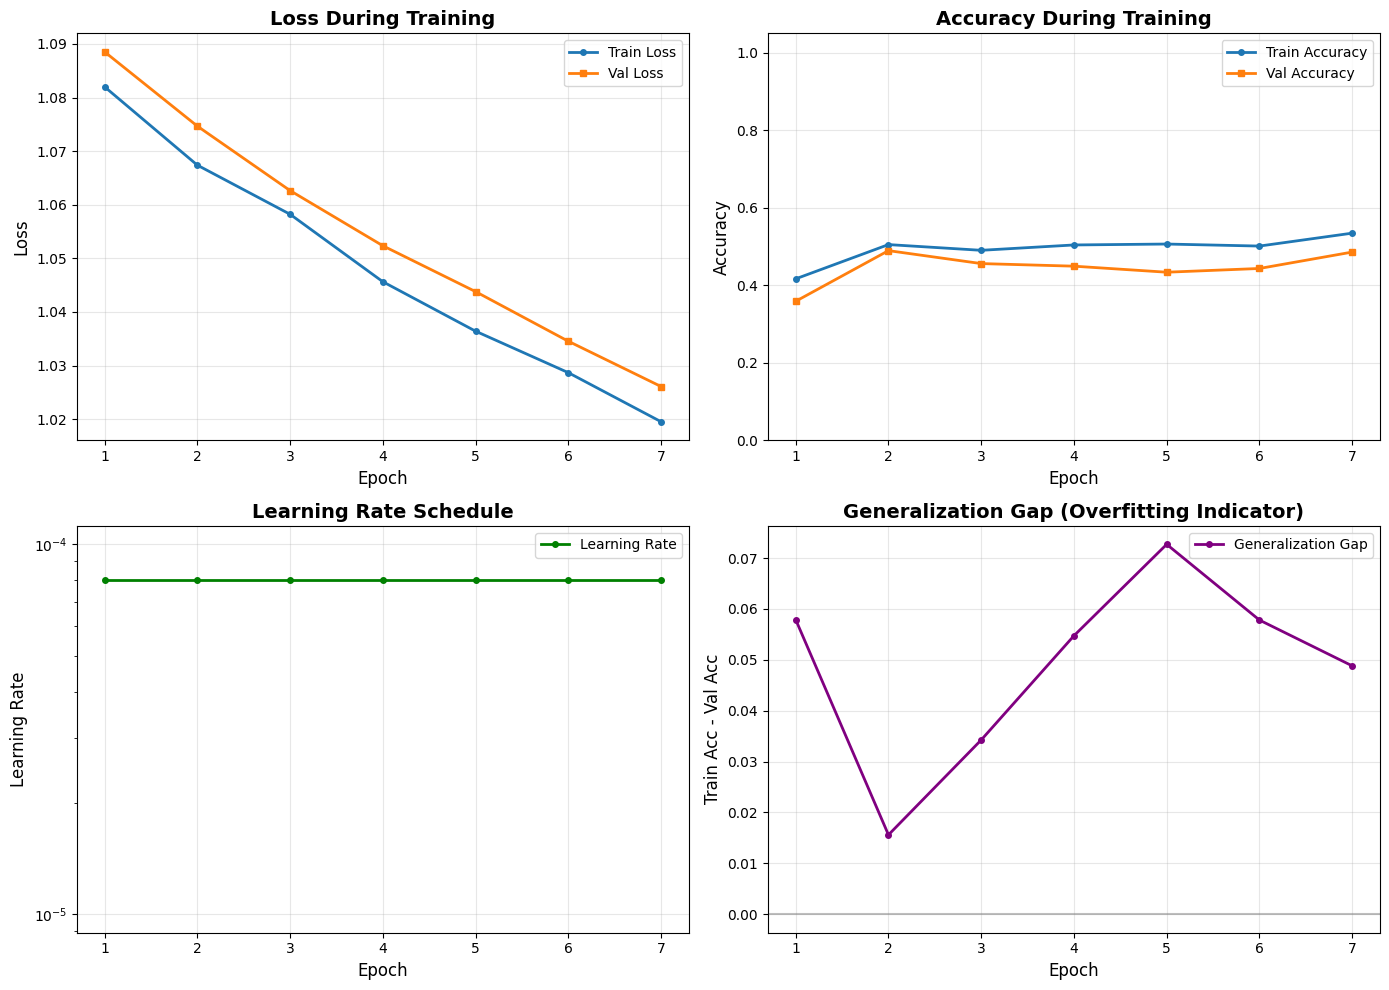


Training Summary
Total Epochs Trained: 7
Best Train Accuracy: 0.5343
Best Val Accuracy: 0.4892 (Epoch 2)
Final Test Accuracy: 0.4985


In [13]:
# ============================================
# Training Graphs
# ============================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# Graph 1: Loss (Train vs Val)
axes[0, 0].plot(epochs, history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], label='Val Loss', marker='s', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Graph 2: Accuracy (Train vs Val)
axes[0, 1].plot(epochs, history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_acc'], label='Val Accuracy', marker='s', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1.05])

# Graph 3: Learning Rate Curve
axes[1, 0].plot(epochs, history['lr'], label='Learning Rate', marker='o', linewidth=2, markersize=4, color='green')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# Graph 4: Generalization Gap (Train Acc - Val Acc)
gen_gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(epochs, gen_gap, label='Generalization Gap', marker='o', linewidth=2, markersize=4, color='purple')
axes[1, 1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Train Acc - Val Acc', fontsize=12)
axes[1, 1].set_title('Generalization Gap (Overfitting Indicator)', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Training Summary (Stage A Only)
# ============================================
print("\n" + "="*60)
print("Training Summary")
print("="*60)
print(f"Total Epochs Trained: {len(history['train_acc'])}")
print(f"Best Train Accuracy: {max(history['train_acc']):.4f}")
print(f"Best Val Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Final Test Accuracy: {test_acc:.4f}")


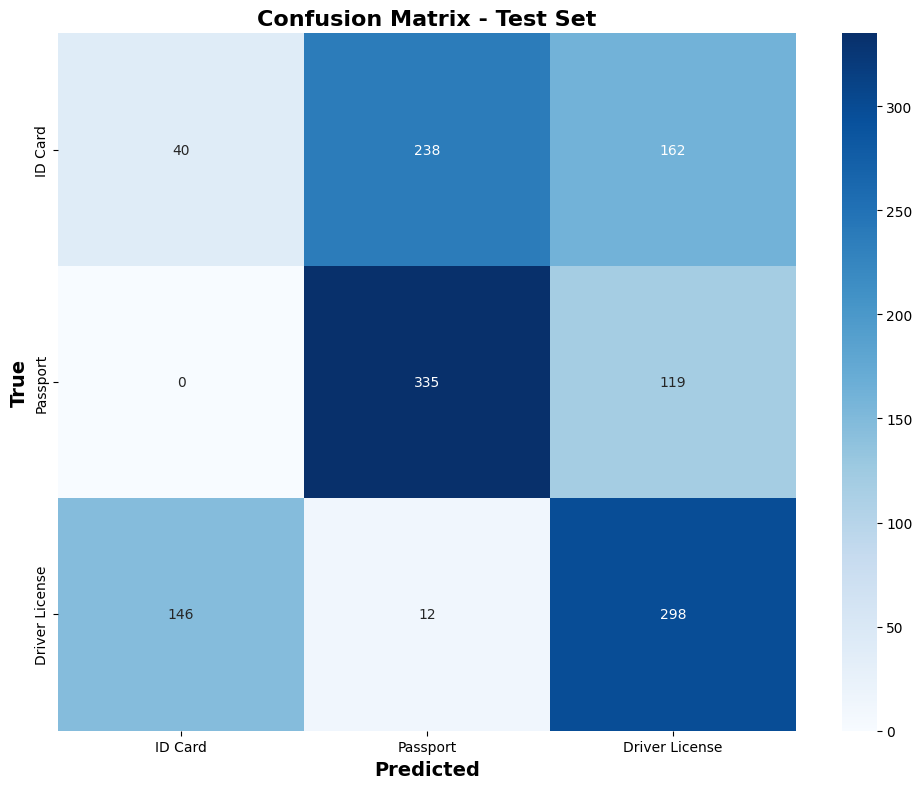


Classification Report
                precision    recall  f1-score   support

       ID Card       0.22      0.09      0.13       440
      Passport       0.57      0.74      0.64       454
Driver License       0.51      0.65      0.58       456

      accuracy                           0.50      1350
     macro avg       0.43      0.49      0.45      1350
  weighted avg       0.44      0.50      0.45      1350



In [14]:
# ============================================
# Confusion Matrix
# ============================================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Collect predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create confusion matrix
labels = ["ID Card", "Passport", "Driver License"]
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted', fontsize=14, fontweight='bold')
plt.ylabel('True', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print classification report
print("\n" + "="*60)
print("Classification Report")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=labels))

## Test on External Images

Load and test the model on images from the test directory to see real-world predictions.


In [15]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Label mapping
label_map = {
    0: "ID Card",
    1: "Passport",
    2: "Driver License"
}

# Test images directory
test_dir = Path("/Users/roy-siftt/final-project/datasets/test")

# Find all JPEG images in test directory
test_images = list(test_dir.glob("*.jpeg")) + list(test_dir.glob("*.jpg")) + list(test_dir.glob("*.JPEG")) + list(test_dir.glob("*.JPG"))

print(f"Found {len(test_images)} images in test directory:")
for img_path in test_images:
    print(f"  - {img_path.name}")

if len(test_images) == 0:
    print("⚠️  No images found in test directory!")
else:
    # Ensure model is in eval mode
    model.eval()
    
    # Use the same transform as validation/test (Albumentations)
    test_transform = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=(0.485, 0.456, 0.406), 
            std=(0.229, 0.224, 0.225)
        ),
        ToTensorV2(),
    ])
    
    # Calculate grid dimensions for better display
    num_images = len(test_images)
    cols = 5  # Number of columns
    rows = (num_images + cols - 1) // cols  # Calculate rows needed
    
    # Create figure with appropriate size
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))
    
    # Flatten axes array for easier indexing
    if rows == 1:
        axes = axes.reshape(1, -1) if num_images > 1 else [axes]
    axes_flat = axes.flatten() if num_images > 1 else [axes]
    
    # Process each image
    results = []
    
    for idx, img_path in enumerate(test_images):
        try:
            # Load and preprocess image
            img = Image.open(img_path).convert("RGB")
            img_np = np.array(img)
            
            # Apply transform (Albumentations format)
            transformed = test_transform(image=img_np)
            img_tensor = transformed['image'].unsqueeze(0).to(device)
            
            # Make prediction
            with torch.no_grad():
                outputs = model(img_tensor)
                probabilities = F.softmax(outputs, dim=1)
                predicted_class = torch.argmax(outputs, dim=1).item()
                confidence = probabilities[0][predicted_class].item()
            
            # Store results
            results.append({
                'name': img_path.name,
                'predicted': label_map[predicted_class],
                'confidence': confidence,
                'probabilities': {
                    label_map[0]: probabilities[0][0].item(),
                    label_map[1]: probabilities[0][1].item(),
                    label_map[2]: probabilities[0][2].item()
                }
            })
            
            # Display image
            axes_flat[idx].imshow(img)
            axes_flat[idx].axis('off')
            axes_flat[idx].set_title(f"{label_map[predicted_class]}\n({confidence*100:.1f}%)", 
                                    fontsize=10, fontweight='bold')
            
        except Exception as e:
            print(f"❌ Error processing {img_path.name}: {e}")
            axes_flat[idx].text(0.5, 0.5, f"Error:\n{str(e)[:50]}", 
                              ha='center', va='center', fontsize=8, wrap=True)
            axes_flat[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(num_images, len(axes_flat)):
        axes_flat[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\n{'='*80}")
    print(f"📊 Detailed Results for {len(results)} Images")
    print(f"{'='*80}\n")
    
    for i, result in enumerate(results, 1):
        print(f"{i}. 📸 {result['name']}")
        print(f"   🎯 Predicted: {result['predicted']}")
        print(f"   📈 Confidence: {result['confidence']*100:.2f}%")
        print(f"   📋 All Probabilities:")
        for label, prob in result['probabilities'].items():
            marker = "✓" if label == result['predicted'] else " "
            print(f"      {marker} {label}: {prob*100:.2f}%")
        print()
    
    print(f"{'='*80}")
    print(f"✅ Completed testing on {len(test_images)} images")


Found 0 images in test directory:
⚠️  No images found in test directory!


**Save The model file**

In [16]:
# Save model to the notebook directory
import os
import pickle

notebook_dir = "/Users/roy-siftt/final-project/notebooks/document_type_classification/vit"
model_path = os.path.join(notebook_dir, "vit_document_classifier_9000.pth")

# Check if best_model_state exists (from early stopping)
try:
    if 'best_model_state' in locals() or 'best_model_state' in globals():
        if best_model_state is not None:
            # Load best model state into model
            model.load_state_dict(best_model_state)
            print("✓ Loaded best model state (from early stopping) before saving")
            # Save best model
            torch.save(best_model_state, model_path)
            print(f"✓ Best model weights saved to: {model_path}")
            print(f"  (Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch})")
        else:
            # No best model state, save current model
            torch.save(model.state_dict(), model_path)
            print(f"✓ Model weights saved to: {model_path}")
    else:
        # best_model_state variable doesn't exist, save current model
        torch.save(model.state_dict(), model_path)
        print(f"✓ Model weights saved to: {model_path}")
except NameError:
    # Variables don't exist, save current model
    torch.save(model.state_dict(), model_path)
    print(f"✓ Model weights saved to: {model_path}")

# Also save in project root for easy access
root_model_path = "/Users/roy-siftt/final-project/vit_document_classifier_9000.pth"
try:
    if 'best_model_state' in locals() or 'best_model_state' in globals():
        if best_model_state is not None:
            torch.save(best_model_state, root_model_path)
        else:
            torch.save(model.state_dict(), root_model_path)
    else:
        torch.save(model.state_dict(), root_model_path)
    print(f"✓ Model also saved to: {root_model_path}")
except NameError:
    torch.save(model.state_dict(), root_model_path)
    print(f"✓ Model also saved to: {root_model_path}")

# Save label map
label_map = {0: "id_card", 1: "passport", 2: "driver_license"}
label_map_path = os.path.join(notebook_dir, "vit_label_map.pkl")
with open(label_map_path, "wb") as f:
    pickle.dump(label_map, f)
print(f"✓ Label map saved to: {label_map_path}")

# Verify file was created
if os.path.exists(model_path):
    file_size = os.path.getsize(model_path) / (1024 * 1024)  # Size in MB
    print(f"✓ File verified: {model_path} ({file_size:.2f} MB)")
else:
    print(f"⚠️  Warning: File not found at {model_path}")

print("\n" + "="*60)
print("Label Mapping:")
print("="*60)
for idx, name in label_map.items():
    print(f"  {idx} → {name}")


✓ Loaded best model state (from early stopping) before saving
✓ Best model weights saved to: /Users/roy-siftt/final-project/notebooks/document_type_classification/vit/vit_document_classifier_9000.pth
  (Best validation accuracy: 0.4892 at epoch 2)
✓ Model also saved to: /Users/roy-siftt/final-project/vit_document_classifier_9000.pth
✓ Label map saved to: /Users/roy-siftt/final-project/notebooks/document_type_classification/vit/vit_label_map.pkl
✓ File verified: /Users/roy-siftt/final-project/notebooks/document_type_classification/vit/vit_document_classifier_9000.pth (21.13 MB)

Label Mapping:
  0 → id_card
  1 → passport
  2 → driver_license
